# Module 1 — Fluorouracil: Serious Outcomes

What were the serious outcomes reported in fluorouracil cases? This notebook analyzes the `outc` table to characterize outcome severity across the analysis population and by drug regimen.

FAERS outcome codes:

| Code | Outcome |
|------|---------|
| DE | Death |
| HO | Hospitalization |
| LT | Life-threatening |
| DS | Disability |
| RI | Required intervention |
| CA | Congenital anomaly |
| OT | Other serious |

**Prerequisite:** Run `01_5fu_explore.ipynb` first to ensure the `fluorouracil_analysis` table exists in the database.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

In [ ]:


outcomes = pd.read_sql_query("""
SELECT outc_cod, COUNT(*) AS reports
FROM outc
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON outc.primaryid = f.primaryid
GROUP BY outc_cod
ORDER BY reports DESC;
""", conn)

outcomes.head(10)

,outc_cod,reports
0,OT,4720
1,HO,3004
2,DE,760
3,LT,555
4,DS,84
5,CA,4
6,RI,3


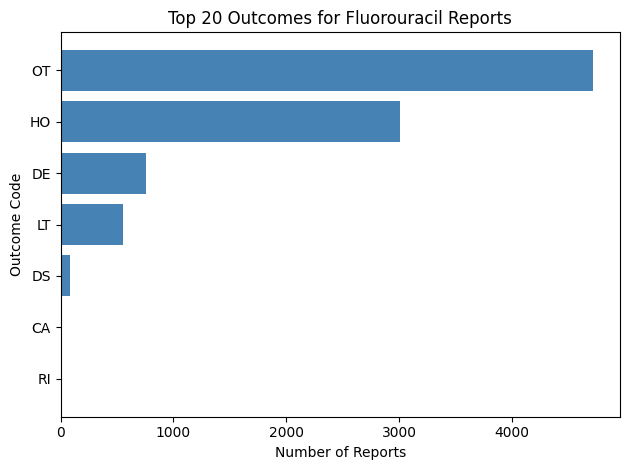

In [ ]:
plt.barh(outcomes['outc_cod'][:20], outcomes['reports'][:20], color='steelblue')
plt.xlabel('Number of Reports')
plt.ylabel('Outcome Code')
plt.title('Top 20 Outcomes for Fluorouracil Reports')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# #
# | Code | Outcome |
# |------|---------|
# | DE | Death |
# | HO | Hospitalization |
# | LT | Life-threatening |
# | DS | Disability |
# | RI | Required intervention |
# | CA | Congenital anomaly |
# | OT | Other serious |


**OT (Other Serious)** dominates because it is a catch-all FAERS category for events the reporter 
considered clinically significant but that did not fit the remaining outcome codes. It cannot be 
broken down further from the `outc` table. The detail is not captured in spontaneous reports.


In [7]:
serious_outcomes_by_FU_regiment = pd.read_sql_query("""
SELECT drug.drugname, outc.outc_cod, COUNT(*) AS reports
FROM drug
JOIN outc ON drug.primaryid = outc.primaryid 
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON drug.primaryid = f.primaryid
WHERE drugname LIKE '%FLUOROURACIL%'
GROUP BY drugname, outc_cod
ORDER BY reports DESC;
""", conn)

serious_outcomes_by_FU_regiment.head(20)

,drugname,outc_cod,reports
0,FLUOROURACIL,OT,10258
1,FLUOROURACIL,HO,6525
2,FLUOROURACIL,DE,1462
3,FLUOROURACIL,LT,1412
4,FLUOROURACIL,DS,193
5,FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN,OT,165
6,FLUOROURACIL SODIUM,OT,64
7,FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN,DE,64
8,FLUOROURACIL\IRINOTECAN\LEUCOVORIN,OT,52
9,CYCLOPHOSPHAMIDE\EPIRUBICIN HYDROCHLORIDE\FLUO...,DE,43


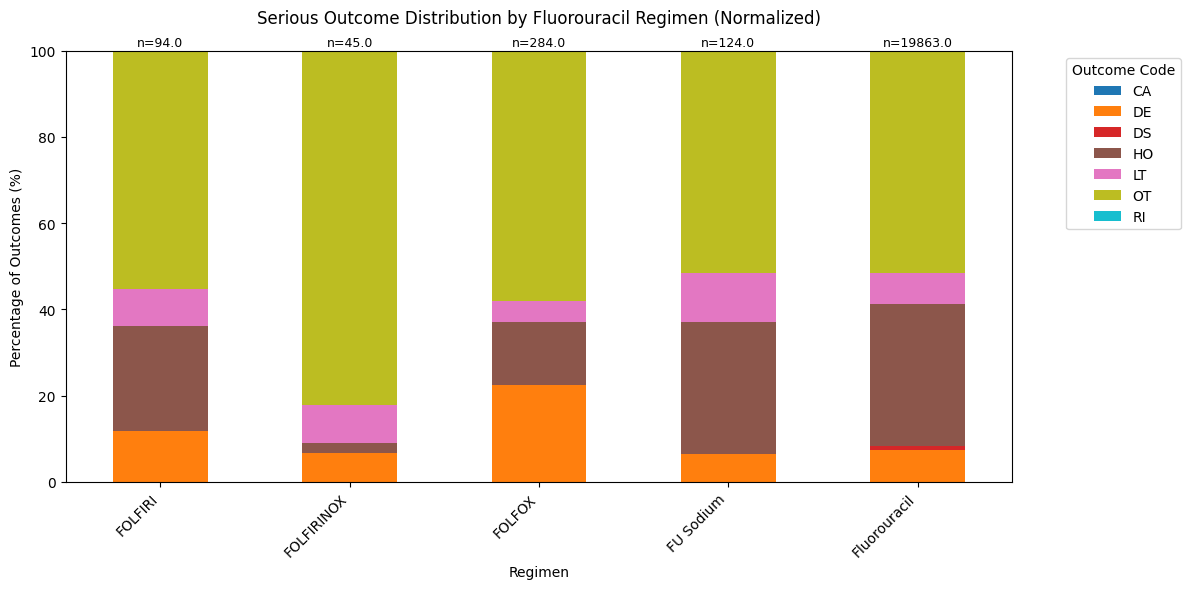

In [14]:
main_regimens = [
    'FLUOROURACIL',
    'FLUOROURACIL\\LEUCOVORIN CALCIUM\\OXALIPLATIN',
    'FLUOROURACIL\\IRINOTECAN\\LEUCOVORIN',
    'FLUOROURACIL SODIUM',
    'FLUOROURACIL\\IRINOTECAN\\LEUCOVORIN\\OXALIPLATIN'
]

name_map = {
    'FLUOROURACIL': 'Fluorouracil',
    'FLUOROURACIL\\LEUCOVORIN CALCIUM\\OXALIPLATIN': 'FOLFOX',
    'FLUOROURACIL\\IRINOTECAN\\LEUCOVORIN': 'FOLFIRI',
    'FLUOROURACIL SODIUM': 'FU Sodium',
    'FLUOROURACIL\\IRINOTECAN\\LEUCOVORIN\\OXALIPLATIN': 'FOLFIRINOX'
}

df = serious_outcomes_by_FU_regiment[
    serious_outcomes_by_FU_regiment['drugname'].isin(main_regimens)
].copy()

df['drugname'] = df['drugname'].map(name_map)

pivot = df.pivot_table(index='outc_cod', columns='drugname', values='reports', fill_value=0)

pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100

pivot_pct.T.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.xlabel('Regimen')
plt.ylabel('Percentage of Outcomes (%)')
plt.title('Serious Outcome Distribution by Fluorouracil Regimen (Normalized)', pad=20)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Outcome Code', bbox_to_anchor=(1.05, 1), loc='upper left')
for i, regimen in enumerate(pivot_pct.columns):
    total = pivot[regimen].sum()
    plt.text(i, 101, f'n={total}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()




| Code | Outcome |
|------|---------|
| DE | Death |
| HO | Hospitalization |
| LT | Life-threatening |
| DS | Disability |
| RI | Required intervention |
| CA | Congenital anomaly |
| OT | Other serious |

**Note:** Combination regimens (FOLFOX, FOLFIRI, FOLFIRINOX) have substantially fewer reports 
than Fluorouracil monotherapy — percentages for these groups should be interpreted cautiously. 
FOLFIRINOX in particular has fewer than 60 records in this dataset.
